In [1]:
 import warnings
 import itertools
 import numpy as np
 import matplotlib.pyplot as plt
 import pandas as pd
 import matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df = pd.read_csv(r"/content/drive/MyDrive/Oyrenme/TimeSeries/Superstore.csv", encoding='latin1')

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
furniture = df.loc[df["Category"] == "Furniture"]

In [12]:
df["Category"].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [13]:
furniture["Order Date"].min(),furniture["Order Date"].max()

('01-02-2011', '31-12-2014')

In [14]:
furniture.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,6,CA-2011-115812,09-06-2011,14-06-2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
10,11,CA-2011-115812,09-06-2011,14-06-2011,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [16]:
furniture = furniture[['Order Date', 'Sales']]
display(furniture.head())

,Order Date,Sales
0,09-11-2013,261.9600
1,09-11-2013,731.9400
3,11-10-2012,957.5775
5,09-06-2011,48.8600
10,09-06-2011,1706.1840


In [17]:
furniture.sort_values("Order Date")

,Order Date,Sales
3365,01-02-2011,290.666
157,01-03-2011,457.568
7949,01-03-2011,63.552
7948,01-03-2011,362.250
6547,01-03-2011,634.116
...,...,...
1545,31-12-2011,1573.488
7681,31-12-2011,605.880
2136,31-12-2012,14.760
7561,31-12-2013,170.786


In [19]:
furniture.isnull().sum()

,0
Order Date,0
Sales,0


In [22]:
furniture = furniture.groupby("Order Date")["Sales"].sum().reset_index()

In [23]:
furniture.head()

,Order Date,Sales
0,01-02-2011,290.6660
1,01-03-2011,1893.9950
2,01-03-2012,1227.9984
3,01-04-2013,327.9960
4,01-04-2014,296.1128


In [24]:
furniture = furniture.set_index("Order Date")

In [26]:
furniture.head()

,Sales
Order Date,
01-02-2011,290.6660
01-03-2011,1893.9950
01-03-2012,1227.9984
01-04-2013,327.9960
01-04-2014,296.1128


In [27]:
y = furniture["Sales"].resample("MS").mean()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

To fix the `TypeError`, we need to ensure the 'Order Date' column is a proper datetime object before setting it as the index. I will first reset the index, convert the 'Order Date' column to datetime, then set it as the index again, and finally apply `resample`.

In [28]:
# Reset the index to make 'Order Date' a regular column again
furniture = furniture.reset_index()

# Convert 'Order Date' to datetime objects
furniture['Order Date'] = pd.to_datetime(furniture['Order Date'], format='%d-%m-%Y')

# Set 'Order Date' as the index again
furniture = furniture.set_index('Order Date')

# Verify the index type
print(furniture.index)

# Now try resampling again
y = furniture['Sales'].resample('MS').mean()
display(y.head())

DatetimeIndex(['2011-02-01', '2011-03-01', '2012-03-01', '2013-04-01',
               '2014-04-01', '2012-05-01', '2013-05-01', '2014-05-01',
               '2011-06-01', '2013-06-01',
               ...
               '2012-07-31', '2012-08-31', '2013-08-31', '2011-10-31',
               '2012-10-31', '2014-10-31', '2011-12-31', '2012-12-31',
               '2013-12-31', '2014-12-31'],
              dtype='datetime64[ns]', name='Order Date', length=890, freq=None)


,Sales
Order Date,
2011-01-01,495.988250
2011-02-01,355.054000
2011-03-01,857.291529
2011-04-01,567.488357
2011-05-01,432.049188


In [29]:
y.head()

,Sales
Order Date,
2011-01-01,495.988250
2011-02-01,355.054000
2011-03-01,857.291529
2011-04-01,567.488357
2011-05-01,432.049188


In [30]:
y["2014":]

,Sales
Order Date,
2014-01-01,397.602133
2014-02-01,528.179800
2014-03-01,557.754316
2014-04-01,452.636345
2014-05-01,664.111623
2014-06-01,768.314805
2014-07-01,661.034429
2014-08-01,828.292556
2014-09-01,1183.910960


In [32]:
furniture_sorted = furniture.sort_index()
display(furniture_sorted["2014":].reset_index().sort_values("Order Date", ascending = True))

,Order Date,Sales
0,2014-01-02,975.4900
1,2014-01-03,913.4300
2,2014-01-09,892.9800
3,2014-01-13,37.6800
4,2014-01-14,212.9400
...,...,...
253,2014-12-25,1393.4940
254,2014-12-26,832.4540
255,2014-12-29,551.2568
256,2014-12-30,2330.7180


In [36]:
furniture_sorted["2011":]

,Sales
Order Date,
2011-01-07,2573.8200
2011-01-08,76.7280
2011-01-11,51.9400
2011-01-12,9.9400
2011-01-14,879.9390
...,...
2014-12-25,1393.4940
2014-12-26,832.4540
2014-12-29,551.2568


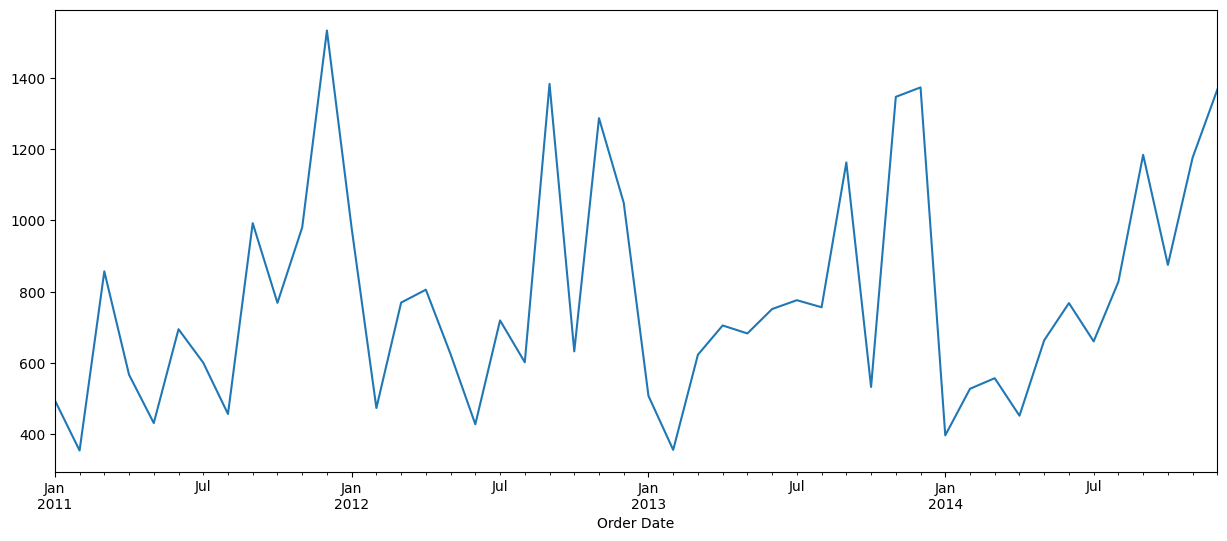

In [39]:
y.plot(figsize=(15, 6))
plt.show()
y_furniture = y

In [42]:
office = df.loc[df["Category"] == "Office Supplies"]
office = office[['Order Date', 'Sales']]
office = office.groupby("Order Date")["Sales"].sum().reset_index()
office['Order Date'] = pd.to_datetime(office['Order Date'], format='%d-%m-%Y')
office = office.set_index("Order Date")
y_office = office["Sales"].resample("MS").mean()
display(y_office.head())

,Sales
Order Date,
2011-01-01,285.357647
2011-02-01,63.042588
2011-03-01,391.176318
2011-04-01,464.794750
2011-05-01,324.346545


In [43]:
furniture_sales = y_furniture
office_sales = y_office

date = pd.DataFrame(furniture_sales.index)
date.columns = ['Order Date']
display(date.head())

,Order Date
0,2011-01-01
1,2011-02-01
2,2011-03-01
3,2011-04-01
4,2011-05-01


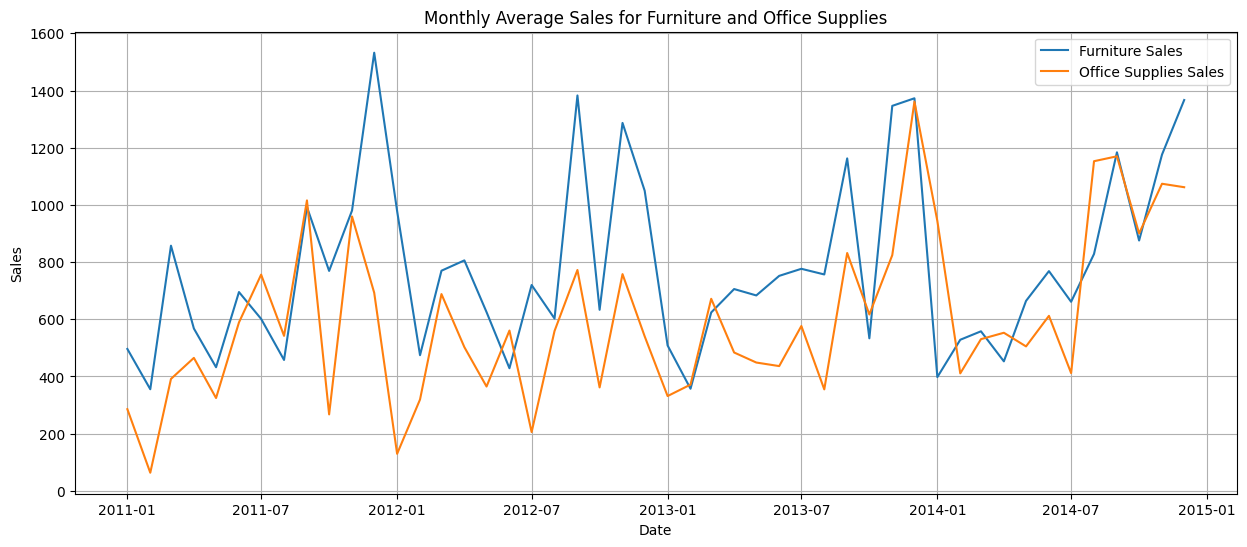

In [44]:
plt.figure(figsize=(15, 6))
plt.plot(furniture_sales.index, furniture_sales.values, label='Furniture Sales')
plt.plot(office_sales.index, office_sales.values, label='Office Supplies Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Monthly Average Sales for Furniture and Office Supplies')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
pip install prophet

In [46]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)

### Forecasting Furniture Sales with Prophet

In [47]:
# Prepare data for Prophet for furniture sales
furniture_prophet = pd.DataFrame({'ds': furniture_sales.index, 'y': furniture_sales.values})
display(furniture_prophet.head())

,ds,y
0,2011-01-01,495.988250
1,2011-02-01,355.054000
2,2011-03-01,857.291529
3,2011-04-01,567.488357
4,2011-05-01,432.049188


In [48]:
# Create and fit the Prophet model for furniture sales
m_furniture = Prophet()
m_furniture.fit(furniture_prophet)

In [49]:
# Create a dataframe with future dates for 3 years (36 months)
future_furniture = m_furniture.make_future_dataframe(periods=36, freq='MS')

# Make predictions
forecast_furniture = m_furniture.predict(future_furniture)

# Display the forecast for furniture sales
display(forecast_furniture[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
79,2017-08-01,746.526365,615.213120,874.438511
80,2017-09-01,1314.513355,1192.095795,1448.403774
81,2017-10-01,754.935534,626.277890,887.646773
82,2017-11-01,1354.877270,1220.797627,1492.227191
83,2017-12-01,1370.138612,1241.330352,1508.508316


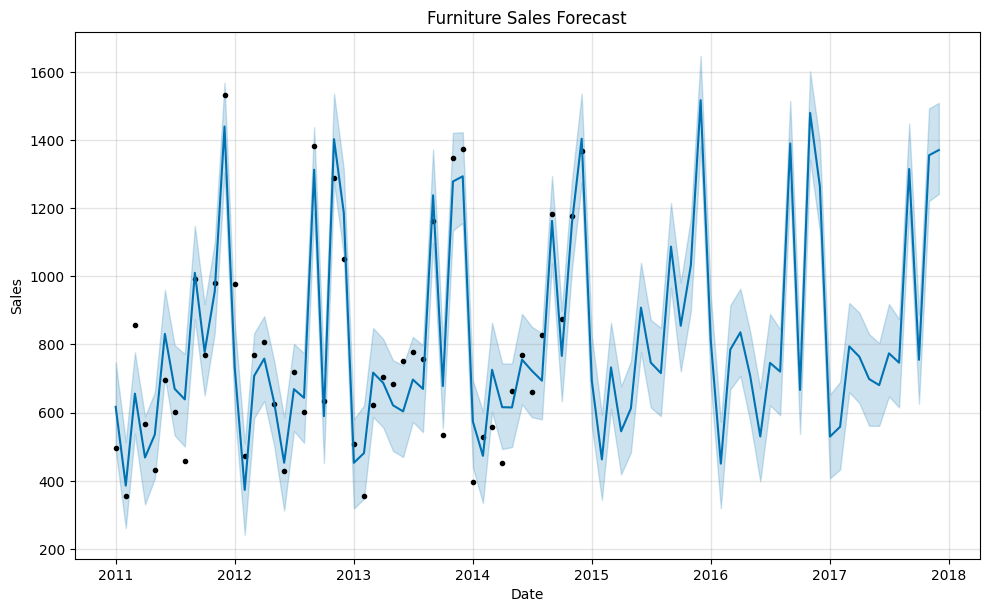

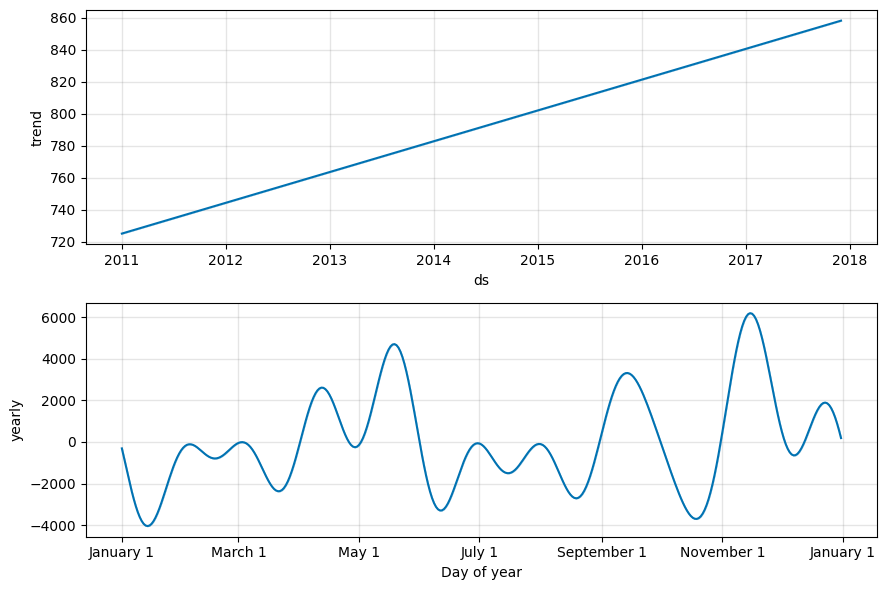

In [50]:
# Plot the forecast for furniture sales
fig_furniture = m_furniture.plot(forecast_furniture)
plt.title('Furniture Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Plot the components of the furniture forecast
fig_furniture_components = m_furniture.plot_components(forecast_furniture)
plt.show()

### Forecasting Office Supplies Sales with Prophet

In [51]:
# Prepare data for Prophet for office supplies sales
office_prophet = pd.DataFrame({'ds': office_sales.index, 'y': office_sales.values})
display(office_prophet.head())

,ds,y
0,2011-01-01,285.357647
1,2011-02-01,63.042588
2,2011-03-01,391.176318
3,2011-04-01,464.794750
4,2011-05-01,324.346545


In [52]:
# Create and fit the Prophet model for office supplies sales
m_office = Prophet()
m_office.fit(office_prophet)

In [53]:
# Create a dataframe with future dates for 3 years (36 months)
future_office = m_office.make_future_dataframe(periods=36, freq='MS')

# Make predictions
forecast_office = m_office.predict(future_office)

# Display the forecast for office supplies sales
display(forecast_office[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
79,2017-08-01,1055.092697,841.942876,1275.743416
80,2017-09-01,1334.169314,1114.019531,1532.740538
81,2017-10-01,964.082618,746.541184,1183.421120
82,2017-11-01,1269.475364,1058.957369,1484.758821
83,2017-12-01,1294.469755,1056.035296,1491.567007


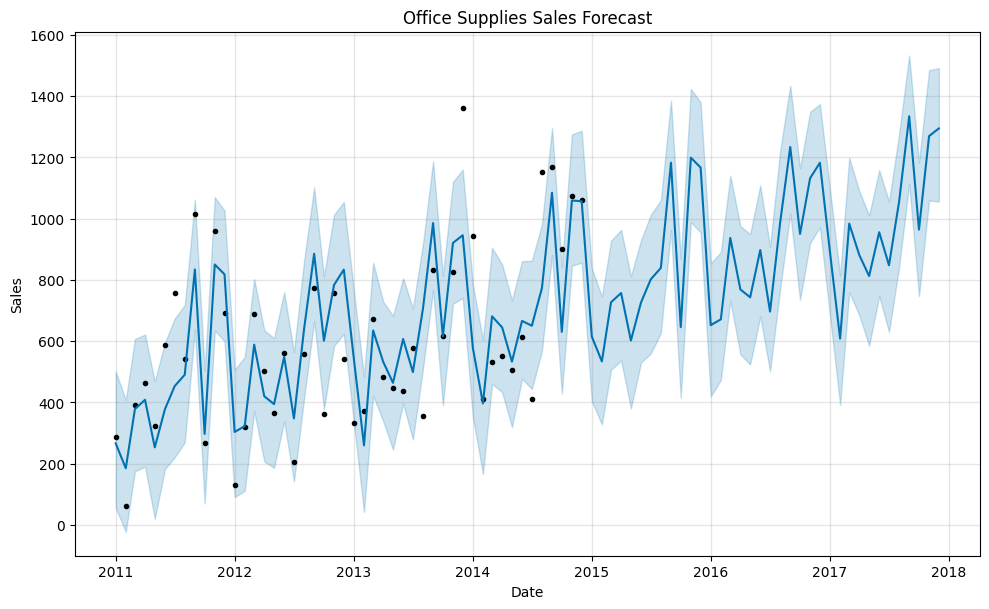

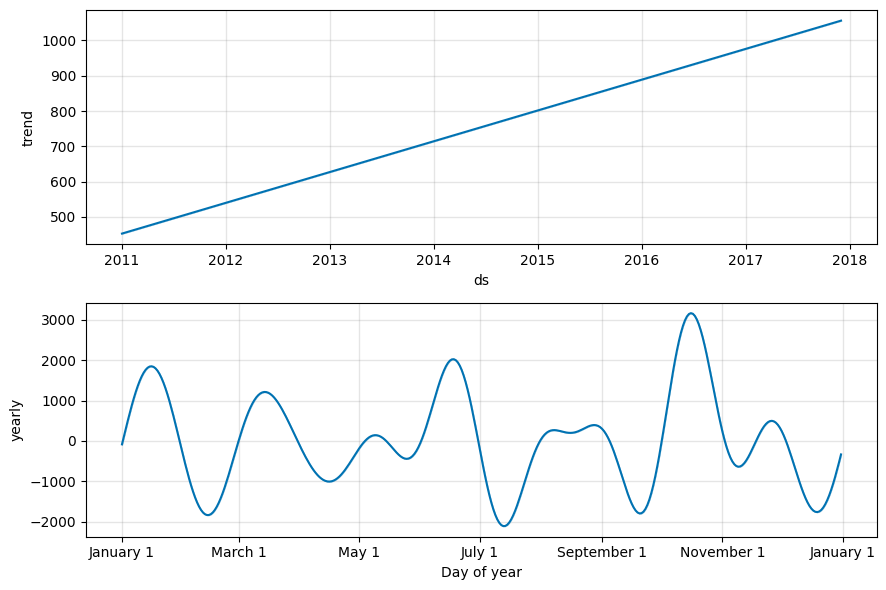

In [54]:
# Plot the forecast for office supplies sales
fig_office = m_office.plot(forecast_office)
plt.title('Office Supplies Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Plot the components of the office supplies forecast
fig_office_components = m_office.plot_components(forecast_office)
plt.show()